Hello,

Welcome to my first time ever doing a project. 

I will be trying to build a number detection neural network with the MNIST dataset!

# Pipeline

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
import os
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("MPS available:", torch.backends.mps.is_available())

In [ ]:

data_path = './MNISTdata'

os.makedirs(data_path, exist_ok=True)

train_dataset_without_transform = torchvision.datasets.MNIST(
    root=data_path,
    train=True,
    download=True
    )

In [ ]:
# Device usage 

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using device: {device}')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f'Using device: {device}')

# Image and label metadata 

img_pil, label = train_dataset_without_transform[0]

print(f'Type: {type(img_pil)}')
print(f'Image dimensions: {img_pil.size}')
print(f'Label type: {type(label)}')
print(f'Label value: {label}')

In [ ]:
test_image = train_dataset_without_transform[0][0]

img_np = np.array(test_image)

plt.imshow(img_np)

In [ ]:
# Converting the images to tensors 

mean = 0.1307
std = 0.3081

train_transform = transforms.Compose([
  transforms.RandomRotation(degrees=15),
  transforms.RandomHorizontalFlip(p=0.5),
  transforms.RandomVerticalFlip(p=0.5),
  transforms.ToTensor(),
  transforms.Normalize(mean=mean, std=std)])

test_transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize(mean=mean, std=std)])

# Loading the train_dataset

train_dataset = torchvision.datasets.MNIST(
    root=data_path,
    download=True,
    train=True,
    transform=train_transform
)

# Loading the test_dataset

test_dataset = torchvision.datasets.MNIST(
    root=data_path,
    download=True,
    train=False,
    transform=train_transform
)

In [ ]:
batch_size = 64

# Data loader for the training set

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Data loader for the test set 

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model

In [ ]:
class simpleNN(nn.Module):
    """
    A simple deep neural network that will be trained to recognise numbers from the MNSIT dataset.
    Images are 28x28
    """
    def __init__(self):
        super(simpleNN, self).__init__()
        # 28x28 input vector to a 784-dimensional vector
        self.flatten = nn.Flatten()
        # Initialise the model's strucutre 
        self.layer = nn.Sequential(
            # One neurone for every input
            nn.Linear(784,128),
            # Applies rectified linear unit 
            nn.ReLU(),
            # Define the second layer 
            nn.Linear(128,10)
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.layer(x)
        return x

In [ ]:
model = simpleNN()

# Loss function
loss_function = nn.CrossEntropyLoss()
# Optimizer 
optimizer = optim.Adam(model.parameters(),lr=0.001)

# Performance and metrics

In [ ]:
def train_epoch(model, device, loss_function, optimizer, train_loader):

    """
    Evaluates the model's accuracy on the train_dataset.

    This function sets the model to training mode, iterates through the training data, performs 
    a forward then backwards pass, and update's the model's weights. It also tracks and prints the 
    loss and accuracy at specified intervals

    Args: 
        model: the nueral network that will be trained
        device: the device (e.g. 'cuda' or 'cpu') on which training will be performed 
        loss_function: the loss function used to calculate the error between predicted output and ground truth
        optimizer: the optimizer used to update the model's weights
        train_loader: the DataLoader providing batches of training data
    Returns:
        A tuple containing:
            - model: trained model
            - avg_epoch_loss: the average loss calculated over all batches in the epoch

    """

    # Ensure model is on the correct device for training
    model = model.to(device)
    # Set model to training mode
    model.train()

    # Initilase tracker for epoch loss
    epoch_loss = 0

    # Initialise trackers for periodic progress reporting 
    running_loss = 0
    num_correct_predictions = 0
    total_predictions = 0
    total_batches = len(train_loader)

    # Iterate over the training data in batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move current image (inputs) and labels (targets) from teh batch to the correct device 
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Get the model's predictions 
        outputs = model(inputs)

        # Get the loss
        loss = loss_function(outputs, targets)

        # Perform backwards sweep
        loss.backward()

        # Update the weights of the model 
        optimizer.step()

        # Accumulate the loss for tracking and reporting
        loss_value = loss.item()
        epoch_loss += loss_value
        running_loss += loss_value

        # Calculate accuracy metrics for the current batch 
        _, predicted_indices = outputs.max(1)
        batch_size = targets.size(0) 
        total_predictions += batch_size
        num_correct_in_batch = predicted_indices.eq(targets).sum().item()
        num_correct_predictions += num_correct_in_batch

        # Check if it's time to print a training update
        if (batch_idx + 1) % 134 == 0 or (batch_idx + 1) == total_batches:
            avg_running_loss = running_loss / 134
            accuracy = 100 * num_correct_predictions/total_predictions

            # Print the updated progress
            print(f'\tStep {batch_idx + 1}/{total_batches} - Loss: {avg_running_loss:.3f} | Acc: {accuracy:.2f}%')

            # Reset the trackers for the next reporting intervals
            running_loss = 0
            num_correct_predictions = 0
            total_predictions = 0
    # Calculate avg loss for the entire epoch
    avg_epoch_loss = epoch_loss / total_batches
    # Returned the trained model and the avg epoch loss
    return model, avg_epoch_loss    

In [ ]:
def evaluate(model, test_loader, device):
    """
    Function that evaluates the model's performance using the test_dataset.

    This function sets the model to evalution, iterates through the test_dataset,
    and calculates the percentage of correct predictions.

    Args:
        model: the trained model
        test_loader: a DataLoader containing the test dataset
        device: the device (e.g. 'cuda' or 'cpu') to run the evaluation on
    Returns:    
    """
    # Set the model to evaluation 
    model.eval()

    # Initialises a counter for the number of correct predictions
    num_correct_predictions = 0

    # Intialises a counter for the total number of predictions
    total_predictions = 0

    # Initialises a list of the certainty value attached to each correct prediction 
    certainty_correct = []
    # Initialises a list of the certainty value attached to each incorrect prediction 
    certainty_incorrect = []

    # Disables gradient calculation
    with torch.no_grad():
        # Iterate over all the batches in the DataLoader
        for inputs, targets in test_loader:
            # Moves input data and targets to specified device
            inputs, targets = inputs.to(device), targets.to(device)

            # Perform a forward pass to get the model's output
            outputs = model(inputs)

            # Get the model's prediction
            prob_of_predicted_indices, predicted_indices = outputs.max(1)

            # Get size of the current batch 
            batch_size = targets.size(0)

            # Adds the batch size to the total number of predictions
            total_predictions += batch_size

            # Gets the total number of of correct predictions in the batch
            num_correct_in_batch = predicted_indices.eq(targets).sum().item()

            # Adds the numebr of correct predictions in a batch to the toal number of correct predictions
            num_correct_predictions += num_correct_in_batch

            # # Check if prediction is correct
            # if predicted_indices == targets:
            #     # Add the certainty value of the predicted indices to certainty_correct counter 
            #     certainty_correct.append(prob_of_predicted_indices)
            # else:
            #     # Add the certainty value of the predicted indices to certainty_incorrect counter 
            #     certainty_incorrect.append(prob_of_predicted_indices)
        # Calculates the accuracy of the model 
        accuracy_percentage = 100 * num_correct_predictions/total_predictions
        # Prints the accuracy 
        print((f'\tAccuracy: {accuracy_percentage:.2f}%'))
        # Calculates the average certainty attached to a correct prediction
        # avg_certainty_correct = sum(certainty_correct)/len(certainty_correct)
        # # Prints the average certainty attached to a correct prediction
        # print((f'\tAccuracy: {avg_certainty_correct:.2f}%'))
        # # Calculates the average certainty attached to an incorrect prediction
        # avg_certainty_incorrect = sum(certainty_incorrect)/len(certainty_incorrect)
        # # Prints the average certainty attached to an nicorrect prediction
        # print((f'\tAccuracy: {avg_certainty_incorrect:.2f}%'))

        return accuracy_percentage

In [ ]:
# Training and testing the model 

num_epochs = 5

# Initialise lists to store model metrics during each training and test epoch
training_loss = []
test_accuracy = []

for epoch in range(num_epochs):
    # Training the model
    print(f"=== Running training epoch; epoch: {epoch+1} ===")
    trained_model, loss = train_epoch(model=model, loss_function=loss_function, optimizer=optimizer, train_loader=train_loader, device=device)
    training_loss.append(loss)

    # Testing the model 
    print(f"=== Testing training epoch; epoch: {epoch+1} ===")
    accuracy = evaluate(model=trained_model, test_loader=test_loader, device=device)
    test_accuracy.append(accuracy)  

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, sharex=True)
 
ax1.plot(range(1,num_epochs+1), training_loss)
ax1.set_title('Loss over epochs')

ax2.plot(range(1,num_epochs+1),test_accuracy, color='orange')
ax2.set_title('Accuracy over epochs')

plt.tight_layout()

In [145]:
import random

def display_predictions(model, test_loader, device):
    """
    Display a grid of predictions for one random sample from each class.

    Args:
        model: the train PyTorch model 
        test_loader: the DataLoader for the test set
        device: The device (e.g. 'cpu' or 'CUDA') to run the inference on

    """
    # Ensures the model is on the specified device and in evalution mode 
    model = model.to(device)
    model.eval()

    # Create a dictionary to store indicies for each class
    class_indices = {i: [] for i in range(10)}

    # Populates the dictionary with the indicies of all samples for each class
    for idx, (_, label) in enumerate(test_loader.dataset):
        class_indices[label].append(idx)
    
    # Selects one random index from the list of the indices for each class
    random_indices = [random.choice(indices) for indices in class_indices.values()]
    
    # Retrieve the images and corresponding labels using the randomly selected indices
    sample_images = torch.stack([test_loader.dataset[i][0] for i in random_indices])
    sample_labels = [test_loader.dataset[i][1] for i in random_indices]

    # Temporarily disable gradient calculation for inference 
    with torch.no_grad():
        # Passes the selected images through the model to get outputs
        outputs = model(sample_images.to(device))
        # Gets the predictions from the model 
        _, predictions = outputs.max(1)

    # Create a figure and a grid of subplots for displaying the images 
    fig, axes = plt.subplots(2, 5, figsize=(12,6))
    # Set a main title for the entire figure 
    fig.suptitle('Model predictions from a sample of each class', fontsize=16)

    # Iterates through the subplots to display each images and its prediction
    for i, ax in enumerate(axes.flat):
        # Extracts and prepares the image, true label, and predicted label for display.
        image = sample_images[i].cpu().squeeze()
        true_label = sample_labels[i]
        predicted_label = predictions[i].item()

        # Displays the image on the current subplot
        ax.imshow(image, cmap='gray')

        # Displays the image on the current subplot, with colour indicating if the prediction is correct 
        title_color = 'green' if true_label == predicted_label else 'red'
        ax.set_title(f"True: {true_label}\nPred: {predicted_label}", color=title_color)

        # Hides axes for cleaner visuals 
        ax.axis('off')

    # Adjusts the layout to prevent titles and labels from overlapping 
    plt.tight_layout(rect=[0,0,1,0.96])

    # Adjusts the vertical spacing between subplots 
    plt.subplots_adjust(hspace=0.3)

    # Displays the plot 
    plt.show()

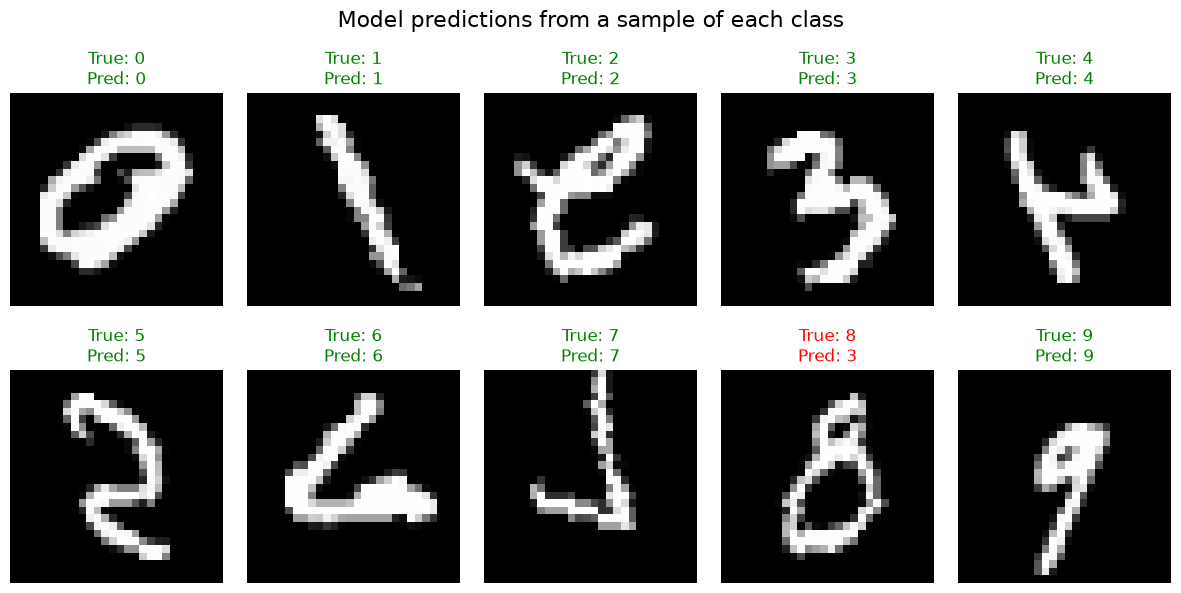

In [144]:
display_predictions(trained_model, test_loader, device)